In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from torch.utils.data import DataLoader

from Training.emotion_dataset import EmotionDataset

from Models.multimodal_model import MultimodalEmotionModel

In [2]:
fusion_df = pd.read_csv(
    "../Outputs/multimodal_features.csv"
)

label_encoder = LabelEncoder()

fusion_df["emotion"] = label_encoder.fit_transform(
    fusion_df["emotion"]
)

psycho_features = fusion_df.iloc[:,2:36].values

hubert_features = fusion_df.iloc[:,36:].values

labels = fusion_df["emotion"].values

print(fusion_df.shape)

(2880, 804)


In [3]:
X_psy_train, X_psy_test, \
X_hubert_train, X_hubert_test, \
y_train, y_test = train_test_split(

    psycho_features,

    hubert_features,

    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels

)

In [4]:
test_dataset = EmotionDataset(

    X_psy_test,

    X_hubert_test,

    y_test

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False

)

In [5]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print(device)

cuda


In [6]:
model = MultimodalEmotionModel(

    psycho_dim=34,

    hubert_dim=768,

    hidden_dim=128,

    num_classes=8

)

model.load_state_dict(

    torch.load(

        "../Models/best_model.pth",

        map_location=device

    )

)

model = model.to(device)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [7]:
all_predictions = []

all_labels = []

model.eval()

with torch.no_grad():

    for psycho_batch, hubert_batch, labels_batch in test_loader:

        psycho_batch = psycho_batch.to(device)

        hubert_batch = hubert_batch.to(device)

        labels_batch = labels_batch.to(device)

        logits, embedding, attention = model(

            psycho_batch,

            hubert_batch

        )

        predictions = torch.argmax(

            logits,

            dim=1

        )

        all_predictions.extend(

            predictions.cpu().numpy()

        )

        all_labels.extend(

            labels_batch.cpu().numpy()

        )

print("Prediction Completed")

Prediction Completed


In [8]:
accuracy = accuracy_score(

    all_labels,

    all_predictions

)

print(

    "Test Accuracy :",

    round(

        accuracy * 100,

        2

    ),

    "%"

)

Test Accuracy : 94.97 %


In [9]:
print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=label_encoder.classes_

    )

)

              precision    recall  f1-score   support

       angry       0.94      0.97      0.95        76
        calm       0.94      0.97      0.96        77
     disgust       1.00      0.92      0.96        77
     fearful       0.95      0.92      0.93        77
       happy       0.96      0.92      0.94        77
     neutral       1.00      1.00      1.00        38
         sad       0.87      0.94      0.90        77
   surprised       0.99      0.97      0.98        77

    accuracy                           0.95       576
   macro avg       0.95      0.95      0.95       576
weighted avg       0.95      0.95      0.95       576



In [10]:
cm = confusion_matrix(

    all_labels,

    all_predictions

)

print(cm)

[[74  0  0  0  1  0  0  1]
 [ 0 75  0  0  0  0  2  0]
 [ 2  0 71  2  0  0  2  0]
 [ 1  0  0 71  0  0  5  0]
 [ 0  2  0  2 71  0  2  0]
 [ 0  0  0  0  0 38  0  0]
 [ 2  3  0  0  0  0 72  0]
 [ 0  0  0  0  2  0  0 75]]


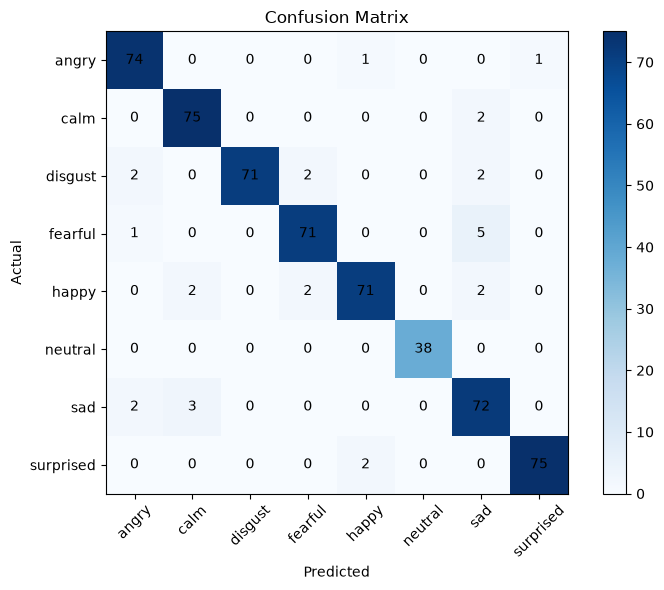

In [11]:
plt.figure(figsize=(8,6))

plt.imshow(

    cm,

    cmap="Blues"

)

plt.colorbar()

plt.xticks(

    np.arange(len(label_encoder.classes_)),

    label_encoder.classes_,

    rotation=45

)

plt.yticks(

    np.arange(len(label_encoder.classes_)),

    label_encoder.classes_

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center",

            color="black"

        )

plt.tight_layout()

plt.show()

In [12]:
report = classification_report(

    all_labels,

    all_predictions,

    target_names=label_encoder.classes_

)

with open(

    "../Evaluation/classification_report.txt",

    "w"

) as file:

    file.write(report)

print("Classification Report Saved")

Classification Report Saved


In [13]:
pd.DataFrame(

    cm,

    index=label_encoder.classes_,

    columns=label_encoder.classes_

).to_csv(

    "../Evaluation/confusion_matrix.csv"

)

print("Confusion Matrix Saved")

Confusion Matrix Saved
